# DCC

In [48]:
import tensorflow as tf
from tensorflow.keras.datasets import mnist

(x_train, y_train), (x_test, y_test) = mnist.load_data()

x_train=tf.keras.utils.normalize(x_train, axis=1)  #convert all the values between 0 and 1-> easier for the system to calculate
x_test=tf.keras.utils.normalize(x_test, axis=1)

model=tf.keras.Sequential([
    tf.keras.layers.Input(shape=(28, 28)),
    tf.keras.layers.Flatten(),
    tf.keras.layers.Dense(128, activation='relu', input_shape=(28*28,)),
    tf.keras.layers.Dense(128, activation='relu',name="features"),
    tf.keras.layers.Dense(10, activation='softmax')
])

#adam: adapts learning rates automatically, fast and stable
#cross entropy loss is used for classification. used when labels are integers; categorical_crossentropy->one-hot encoded
#metrics=['accuracy'] means: After each epoch, show me accuracy.
model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])
model.fit(x_train, y_train, epochs=3)



Epoch 1/3


/home/jan-ole/PycharmProjects/MMP4/.venv/lib/python3.11/site-packages/keras/src/layers/core/dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


1875/1875 ━━━━━━━━━━━━━━━━━━━━ 2s 733us/step - accuracy: 0.9207 - loss: 0.2692
Epoch 2/3
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 1s 743us/step - accuracy: 0.9657 - loss: 0.1110
Epoch 3/3
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 1s 749us/step - accuracy: 0.9760 - loss: 0.0762


y:  5


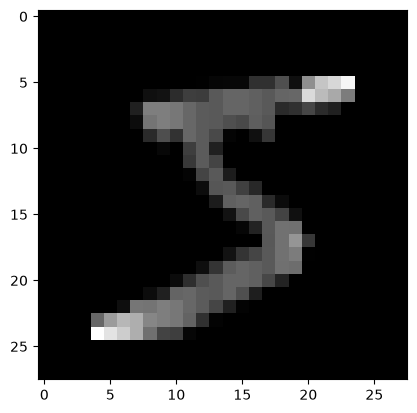

In [49]:
import matplotlib.pyplot as plt
plt.imshow(x_train[0], cmap='gray')
#plt.show()
print("y: ",y_train[0])

313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 575us/step - accuracy: 0.9696 - loss: 0.0961
Test accuracy: 0.9696
313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 401us/step
Feature shape: (10000, 128)


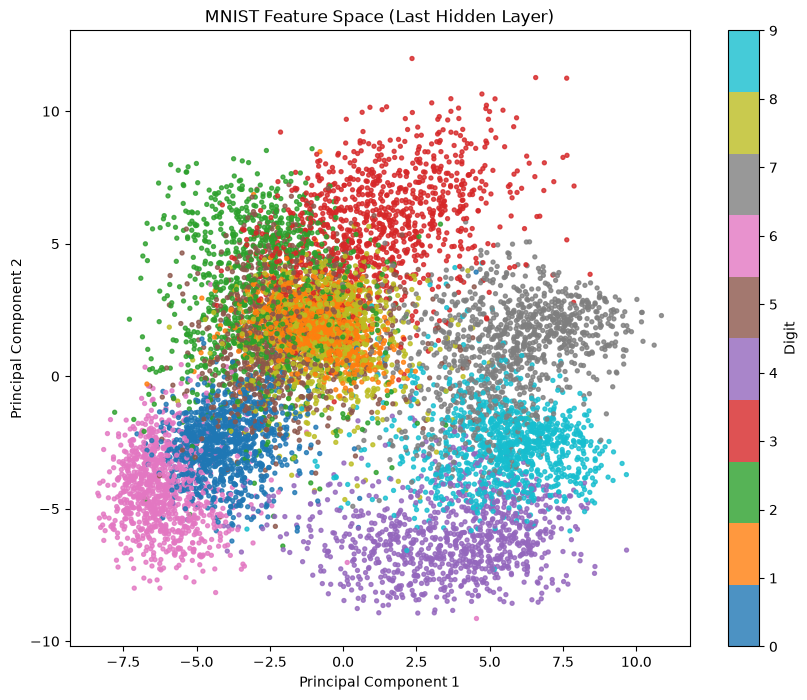

In [50]:
from sklearn.decomposition import PCA
# ----------------------------
# Evaluate
# ----------------------------
test_loss, test_acc = model.evaluate(x_test, y_test)

print(f"Test accuracy: {test_acc:.4f}")

# ----------------------------
# Create a model that outputs the last hidden layer
# ----------------------------
#model.build((None, 28, 28))

feature_model = tf.keras.Model(
    inputs=model.inputs,
    outputs=model.get_layer("features").output
)

# Extract 128-dimensional features
features = feature_model.predict(x_test)

print("Feature shape:", features.shape)
# (10000, 128)

# ----------------------------
# Reduce to 2 dimensions using PCA
# ----------------------------
pca = PCA(n_components=2)
features_2d = pca.fit_transform(features)

# ----------------------------
# Plot
# ----------------------------
plt.figure(figsize=(10, 8))

scatter = plt.scatter(
    features_2d[:, 0],
    features_2d[:, 1],
    c=y_test,
    cmap='tab10',
    s=8,
    alpha=0.8
)

plt.colorbar(scatter, ticks=range(10), label="Digit")
plt.title("MNIST Feature Space (Last Hidden Layer)")
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")

plt.show()

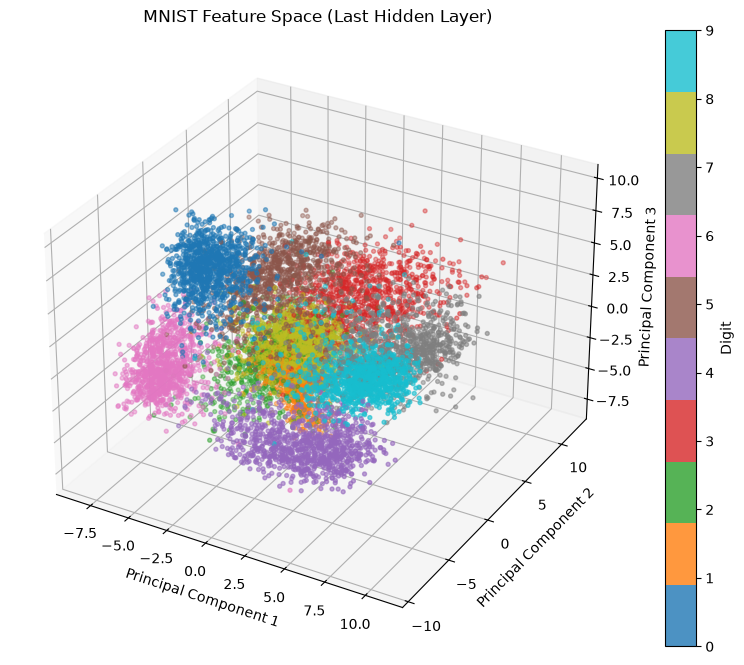

In [51]:
from mpl_toolkits.mplot3d import Axes3D  # Optional in newer Matplotlib versions

# ----------------------------
# Reduce to 3 dimensions using PCA
# ----------------------------
pca3d = PCA(n_components=3)
features_3d = pca3d.fit_transform(features)

# ----------------------------
# Create a 3D figure
# ----------------------------
fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot(111, projection='3d')

scatter = ax.scatter(
    features_3d[:, 0],   # x
    features_3d[:, 1],   # y
    features_3d[:, 2],   # z
    c=y_test,
    cmap='tab10',
    s=8,
    alpha=0.8
)

fig.colorbar(scatter, ticks=range(10), label="Digit")

ax.set_title("MNIST Feature Space (Last Hidden Layer)")
ax.set_xlabel("Principal Component 1")
ax.set_ylabel("Principal Component 2")
ax.set_zlabel("Principal Component 3")

plt.show()

313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 473us/step



KeyboardInterrupt



KeyboardInterrupt: 

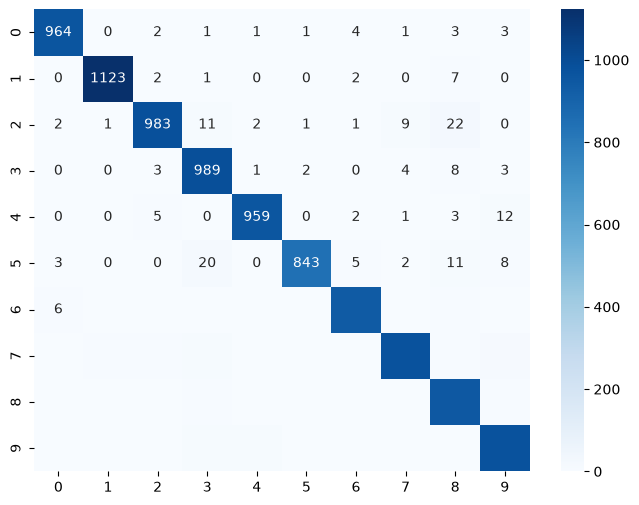

In [52]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

y_pred = model.predict(x_test)
y_pred_classes = np.argmax(y_pred, axis=1)
cm = confusion_matrix(y_test, y_pred_classes)

plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Confusion Matrix")
plt.show()

In [ ]:
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred_classes))

# DNN-2

## underfitting? -> No

Epoch 1/20
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 2s 697us/step - accuracy: 0.1346 - loss: 2.3491 - val_accuracy: 0.1490 - val_loss: 2.3026
Epoch 2/20
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 1s 675us/step - accuracy: 0.1423 - loss: 2.3027 - val_accuracy: 0.1330 - val_loss: 2.3026
Epoch 3/20
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 1s 650us/step - accuracy: 0.1307 - loss: 2.3026 - val_accuracy: 0.1330 - val_loss: 2.3026
Epoch 4/20
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 1s 652us/step - accuracy: 0.1307 - loss: 2.3026 - val_accuracy: 0.1330 - val_loss: 2.3026
Epoch 5/20
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 1s 647us/step - accuracy: 0.1307 - loss: 2.3026 - val_accuracy: 0.1330 - val_loss: 2.3026
Epoch 6/20
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 1s 637us/step - accuracy: 0.1307 - loss: 2.3026 - val_accuracy: 0.1330 - val_loss: 2.3026
Epoch 7/20
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 1s 657us/step - accuracy: 0.1307 - loss: 2.3026 - val_accuracy: 0.1330 - val_loss: 2.3026
Epoch 8/20
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 1s 660us/step - accuracy: 0.1307 -

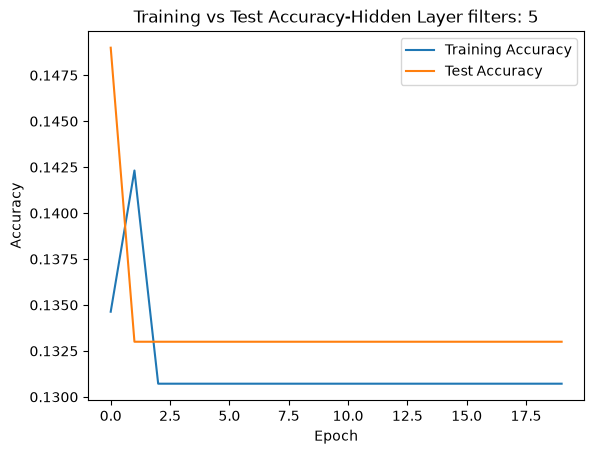

In [68]:
from tensorflow.keras.callbacks import EarlyStopping

model_test=tf.keras.Sequential([
tf.keras.layers.Input(shape=(28, 28)),
tf.keras.layers.Flatten(),
tf.keras.layers.Dense(50, activation='relu'),
tf.keras.layers.Dense(50, activation='relu',name="features"),
tf.keras.layers.Dense(10, activation='softmax')
])

early_stop = EarlyStopping(
    monitor='val_accuracy',   # or 'val_loss'
    patience=2,               # how many epochs to wait before stopping
    restore_best_weights=True # keeps best model automatically
)

#adam: adapts learning rates automatically, fast and stable
#cross entropy loss is used for classification. used when labels are integers; categorical_crossentropy->one-hot encoded
#metrics=['accuracy'] means: After each epoch, show me accuracy.
model_test.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])
history = model_test.fit(
    x_train,
    y_train,
    epochs=20,
    validation_data=(x_test, y_test),  # this gives test/validation accuracy per epoch
    # callbacks=[early_stop]
)

#test_loss, test_acc = model.evaluate(x_test, y_test)

#print(f"Test accuracy: {test_acc:.4f}, Test loss: {test_loss:.4f}")
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Test Accuracy')

plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.title('Training vs Test Accuracy-Hidden Layer filters: 5')
plt.legend()
plt.show()

### 1 hidden layer: 8 neurons

In [ ]:
from tensorflow.keras.callbacks import EarlyStopping

model_test=tf.keras.Sequential([
tf.keras.layers.Input(shape=(28, 28)),
tf.keras.layers.Flatten(),
tf.keras.layers.Dense(8, activation='relu'),
#tf.keras.layers.Dense(20, activation='relu',name="features"),
tf.keras.layers.Dense(10, activation='softmax')
])

early_stop = EarlyStopping(
    monitor='val_accuracy',   # or 'val_loss'
    patience=2,               # how many epochs to wait before stopping
    restore_best_weights=True # keeps best model automatically
)

#adam: adapts learning rates automatically, fast and stable
#cross entropy loss is used for classification. used when labels are integers; categorical_crossentropy->one-hot encoded
#metrics=['accuracy'] means: After each epoch, show me accuracy.
model_test.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])
history = model_test.fit(
    x_train,
    y_train,
    epochs=5,
    validation_data=(x_test, y_test),  # this gives test/validation accuracy per epoch
    callbacks=[early_stop]
)

#test_loss, test_acc = model.evaluate(x_test, y_test)

#print(f"Test accuracy: {test_acc:.4f}, Test loss: {test_loss:.4f}")
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Test Accuracy')

plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.title('Training vs Test Accuracy-Hidden Layer filters: 5')
plt.legend()
plt.show()

### 2 hidden layers: 4 for each

In [ ]:
from tensorflow.keras.callbacks import EarlyStopping

model_test=tf.keras.Sequential([
tf.keras.layers.Input(shape=(28, 28)),
tf.keras.layers.Flatten(),
tf.keras.layers.Dense(4, activation='relu'),
tf.keras.layers.Dense(4, activation='relu',name="features"),
tf.keras.layers.Dense(10, activation='softmax')
])

early_stop = EarlyStopping(
    monitor='val_accuracy',   # or 'val_loss'
    patience=2,               # how many epochs to wait before stopping
    restore_best_weights=True # keeps best model automatically
)

#adam: adapts learning rates automatically, fast and stable
#cross entropy loss is used for classification. used when labels are integers; categorical_crossentropy->one-hot encoded
#metrics=['accuracy'] means: After each epoch, show me accuracy.
model_test.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])
history = model_test.fit(
    x_train,
    y_train,
    epochs=5,
    validation_data=(x_test, y_test),  # this gives test/validation accuracy per epoch
    callbacks=[early_stop]
)

#test_loss, test_acc = model.evaluate(x_test, y_test)

#print(f"Test accuracy: {test_acc:.4f}, Test loss: {test_loss:.4f}")
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Test Accuracy')

plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.title('Training vs Test Accuracy-Hidden Layer filters: 5')
plt.legend()
plt.show()

In [ ]:
def model_num_of_neurons_in_hidden_layer(num_of_neurons):

    model=tf.keras.Sequential([
    tf.keras.layers.Input(shape=(28, 28)),
    tf.keras.layers.Flatten(),
    tf.keras.layers.Dense(num_of_neurons, activation='relu'),
    #tf.keras.layers.Dense(20, activation='relu',name="features"),
    tf.keras.layers.Dense(10, activation='softmax')
    ])

    #adam: adapts learning rates automatically, fast and stable
    #cross entropy loss is used for classification. used when labels are integers; categorical_crossentropy->one-hot encoded
    #metrics=['accuracy'] means: After each epoch, show me accuracy.
    model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])
    history = model.fit(
        x_train,
        y_train,
        epochs=3,
        validation_data=(x_test, y_test)  # this gives test/validation accuracy per epoch
    )

    #test_loss, test_acc = model.evaluate(x_test, y_test)

    #print(f"Test accuracy: {test_acc:.4f}, Test loss: {test_loss:.4f}")
    plt.plot(history.history['accuracy'], label='Training Accuracy')
    plt.plot(history.history['val_accuracy'], label='Test Accuracy')

    plt.xlabel('Epoch')
    plt.ylabel('Accuracy')
    plt.title(f'Training vs Test Accuracy (Hidden Layer neurons: {num_of_neurons})')
    plt.legend()
    plt.show()



In [ ]:
for n in range(128,256,30):
    model_num_of_neurons_in_hidden_layer(n)

In [ ]:
def model_num_of_neurons_in_2_hidden_layer(num_of_neurons, number_of_epochs):

    model=tf.keras.Sequential([
    tf.keras.layers.Input(shape=(28, 28)),
    tf.keras.layers.Flatten(),
    tf.keras.layers.Dense(num_of_neurons, activation='relu'),
    tf.keras.layers.Dense(num_of_neurons, activation='relu',name="features"),
    tf.keras.layers.Dense(10, activation='softmax')
    ])

    #adam: adapts learning rates automatically, fast and stable
    #cross entropy loss is used for classification. used when labels are integers; categorical_crossentropy->one-hot encoded
    #metrics=['accuracy'] means: After each epoch, show me accuracy.
    model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])
    history = model.fit(
        x_train,
        y_train,
        epochs=number_of_epochs,
        validation_data=(x_test, y_test)  # this gives test/validation accuracy per epoch
    )

    #test_loss, test_acc = model.evaluate(x_test, y_test)

    #print(f"Test accuracy: {test_acc:.4f}, Test loss: {test_loss:.4f}")
    plt.plot(history.history['accuracy'], label='Training Accuracy')
    plt.plot(history.history['val_accuracy'], label='Test Accuracy')

    plt.xlabel('Epoch')
    plt.ylabel('Accuracy')
    plt.title(f'Training vs Test Accuracy (Hidden Layer neurons: {num_of_neurons})')
    plt.legend()
    plt.show()

## overfitting

In [ ]:
for n in range(128,150,5):
    model_num_of_neurons_in_2_hidden_layer(n, 10)

In [ ]:
def model_numOfNeurons_numOfLayers_numOfEpochs(num_of_neurons, num_of_layers,number_of_epochs):

    inputs = tf.keras.Input(shape=(28, 28))

    x = tf.keras.layers.Flatten()(inputs)
    hidden_layer = tf.keras.layers.Dense(num_of_neurons, activation="relu")(x)
    for n in range(num_of_layers):
        hidden_layer = tf.keras.layers.Dense(num_of_neurons, activation="relu")(hidden_layer)

    outputs = tf.keras.layers.Dense(10, activation="softmax")(hidden_layer)

    model = tf.keras.Model(inputs=inputs, outputs=outputs)

    early_stop = EarlyStopping(
    monitor='val_accuracy',   # or 'val_loss'
    patience=2,               # how many epochs to wait before stopping
    restore_best_weights=True # keeps best model automatically
)

    #adam: adapts learning rates automatically, fast and stable
    #cross entropy loss is used for classification. used when labels are integers; categorical_crossentropy->one-hot encoded
    #metrics=['accuracy'] means: After each epoch, show me accuracy.
    model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])
    history = model.fit(
        x_train,
        y_train,
        epochs=number_of_epochs,
        validation_data=(x_test, y_test),  # this gives test/validation accuracy per epoch
        callbacks=[early_stop]

    )

    model.summary()

    plt.plot(history.history['accuracy'], label='Training Accuracy')
    plt.plot(history.history['val_accuracy'], label='Test Accuracy')

    plt.xlabel('Epoch')
    plt.ylabel('Accuracy')
    plt.title(f'Training vs Test Accuracy (Hidden Layer neurons: {num_of_neurons})')
    plt.legend()
    plt.show()

In [ ]:
for n in range(20,50,4):
    model_numOfNeurons_numOfLayers_numOfEpochs(n, 3, 10)

## with dropout:


In [ ]:
def model_numOfNeurons_numOfLayers_numOfEpochs_withDropout(num_of_neurons, num_of_layers,number_of_epochs):

    inputs = tf.keras.Input(shape=(28, 28))

    x = tf.keras.layers.Flatten()(inputs)
    for n in range(num_of_layers):
        x = tf.keras.layers.Dense(num_of_neurons, activation="relu")(x)
        x = tf.keras.layers.Dropout(0.3)(x)

    outputs = tf.keras.layers.Dense(10, activation="softmax")(x)

    model = tf.keras.Model(inputs=inputs, outputs=outputs)

    early_stop = EarlyStopping(
    monitor='val_accuracy',   # or 'val_loss'
    patience=2,               # how many epochs to wait before stopping
    restore_best_weights=True # keeps best model automatically
)

    #adam: adapts learning rates automatically, fast and stable
    #cross entropy loss is used for classification. used when labels are integers; categorical_crossentropy->one-hot encoded
    #metrics=['accuracy'] means: After each epoch, show me accuracy.
    model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])
    history = model.fit(
        x_train,
        y_train,
        epochs=number_of_epochs,
        validation_data=(x_test, y_test),  # this gives test/validation accuracy per epoch
        callbacks=[early_stop]

    )

    model.summary()

    plt.plot(history.history['accuracy'], label='Training Accuracy')
    plt.plot(history.history['val_accuracy'], label='Test Accuracy')

    plt.xlabel('Epoch')
    plt.ylabel('Accuracy')
    plt.title(f'Training vs Test Accuracy (Hidden Layer neurons: {num_of_neurons})')
    plt.legend()
    plt.show()

In [ ]:
for n in range(128,256,50):
    model_numOfNeurons_numOfLayers_numOfEpochs_withDropout(n, 2, 10)

In [ ]:
def model_numOfNeurons_numOfLayers_numOfEpochs_withDropout_nextLayerHalfNeurons(num_of_neurons, num_of_layers,number_of_epochs, degree_dropout=0.3):
    num_of_neurons*=2
    inputs = tf.keras.Input(shape=(28, 28))

    x = tf.keras.layers.Flatten()(inputs)
    for n in range(num_of_layers):
        x = tf.keras.layers.Dense(num_of_neurons//2, activation="relu")(x)
        x = tf.keras.layers.BatchNormalization()(x)
        x = tf.keras.layers.Dropout(degree_dropout)(x)

    outputs = tf.keras.layers.Dense(10, activation="softmax")(x)

    model = tf.keras.Model(inputs=inputs, outputs=outputs)

    early_stop = EarlyStopping(
    monitor='val_accuracy',   # or 'val_loss'
    patience=2,               # how many epochs to wait before stopping
    restore_best_weights=True # keeps best model automatically
)

    #adam: adapts learning rates automatically, fast and stable
    #cross entropy loss is used for classification. used when labels are integers; categorical_crossentropy->one-hot encoded
    #metrics=['accuracy'] means: After each epoch, show me accuracy.
    model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])
    history = model.fit(
        x_train,
        y_train,
        epochs=number_of_epochs,
        validation_data=(x_test, y_test),  # this gives test/validation accuracy per epoch
        callbacks=[early_stop]

    )

    model.summary()

    plt.plot(history.history['accuracy'], label='Training Accuracy')
    plt.plot(history.history['val_accuracy'], label='Test Accuracy')

    plt.xlabel('Epoch')
    plt.ylabel('Accuracy')
    plt.title(f'Training vs Test Accuracy (Hidden Layer neurons: {num_of_neurons})')
    plt.legend()
    plt.show()

In [ ]:
for n in [128, 256,512, 1024]:
    model_numOfNeurons_numOfLayers_numOfEpochs_withDropout_nextLayerHalfNeurons(n, 4, 10)

### notes:

👉 The “turning points” of the decision boundary depend mainly on:

number of layers (depth) → most important
activation functions (nonlinearity) → crucial
number of neurons (width) → affects complexity, but not in a simple “#weights = #turns” way

1. If there were NO hidden layers (just one layer)

Example:

logistic regression or single Dense layer

👉 Decision boundary = a straight line (or hyperplane)
No turning points at all.

2. With 1 hidden layer

Even with just one hidden layer:

👉 The network can form piecewise linear boundaries

So instead of a straight line, you get:

multiple line segments
bends (“turning points”)

But:

The number of bends is roughly related to the number of neurons in the hidden layer, NOT weights.

3. With more layers (deep network)

Adding more layers:

composes these piecewise linear regions
creates much more complex bending
increases the number of possible linear regions exponentially in some cases

👉 So depth increases complexity much more efficiently than width.

🔥 Intuition

Think of it like this:

Each neuron creates a “bend” in space (a ReLU breakpoint)
Each layer recombines those bends
More layers = bends of bends of bends

### difference between number of neurons and number of weights:

DNN
eg: Dense(4, input_dim=28*28)
-num of neurons: 4
-number of weights(one weight per input feature):  28*28*4
-num of parameters: 28*28*4+4(4 bias)

CNN
Input: 28 × 28 (1 channel, like MNIST)
Kernel: 3 × 3
Number of filters: 4
-number of neurons (In CNNs, a “neuron” is often: one value in the feature map. So after convolution: Output shape = 28 × 28 × 4 (assuming stride 1, same padding)):
-number of weights: 3*3*4
-number of parameters: 3*3*4+4

### how does the number of neurons affact the performance

The number of neurons (width of a layer) affects model performance mainly through capacity — how complex a function the network can learn.

🧠 1. More neurons → more learning capacity

Each neuron can learn a different feature.

So if you increase neurons:

the model can represent more patterns
decision boundaries become more flexible
performance can improve (up to a point)

👉 Example:

4 neurons → very simple patterns only
64 neurons → many feature combinations
512 neurons → very expressive model

2. But more is NOT always better

After a certain point:

❌ Too few neurons → underfitting
model is too simple
cannot capture structure in data
both train and test accuracy are low
❌ Too many neurons → overfitting
model memorizes training data
training accuracy high, test accuracy worse
poor generalization

# CNN


In [ ]:
from tensorflow.keras import layers, models

# Add channel dimension (important for CNN)
# The -1 tells Python: “Figure out this dimension automatically”
x_train = x_train.reshape(-1, 28, 28, 1)
x_test = x_test.reshape(-1, 28, 28, 1)

# Build CNN model
model = models.Sequential([
    tf.keras.layers.Input(shape=(28, 28, 1)),

    # Convolution block 1
    layers.Conv2D(32, (3, 3), activation='relu'),
    layers.MaxPooling2D((2, 2)),

    # Convolution block 2
    layers.Conv2D(64, (3, 3), activation='relu'),
    layers.MaxPooling2D((2, 2)),

    layers.Conv2D(128, (3, 3), activation='relu'),
    layers.MaxPooling2D((2, 2)),

    # Flatten + Dense layers
    layers.Flatten(),
    layers.Dense(128, activation='relu'),
    layers.Dense(64, activation='relu'),
    layers.Dense(10, activation='softmax')
])


early_stop = EarlyStopping(
    monitor='val_accuracy',   # or 'val_loss'
    patience=2,               # how many epochs to wait before stopping
    restore_best_weights=True # keeps best model automatically
)

# Compile model
model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)



model.summary()

history = model.fit(
    x_train,
    y_train,
    epochs=10,
    validation_data=(x_test, y_test),  # this gives test/validation accuracy per epoch
    callbacks=[early_stop]
)

plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Test Accuracy')

plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.title('CNN Training vs Test Accuracy')
plt.legend()
plt.show()

print(f"Final training accuracy: {history.history['accuracy'][-1]:.4f}")
print(f"Final test accuracy: {history.history['val_accuracy'][-1]:.4f}")

In [ ]:
def cnn(num_of_layers, num_of_epoch, )